# Understanding Fault Propogation through gates

Table of Contents

1. [Motivation](#1-motivation)
2. [Mathematical Foundation](#2-mathematical-foundation)
3. [Gate Conjugation Rule](#3-gate-conjugation-rule)
4. [Single-Qubit Gate Propogation](#4-single-qubit-gate-propogation)
5. [Two-Qubit Gate Propogation](#5-two-qubit-gate-propogation)
6. [Polyoperators & Polyoperations](#6-polyoperators--polyoperations)
7. [General Pauli Tensor Product Propogation](#7-general-pauli-tensor-product-propogation)
8. [Multi-Gate Circuit](#8-multi-gate-circuit)
9. [Noise Model](#9-noise-model)
10. [Stabilizer View](#10-stabilizer-view)
11. [Common Mistakes](#11-common-mistakes)
12. [Cheat Sheet](#12-cheat-sheet)
13. [Formalization for MLIR](#13-formalization-for-mlir)
14. [Glossary](#14-glossary)

## 1) Motivation

Quantum computers operate in an inherently noisy physical environment. Unlike classical bits, qubits are highly sensitive to:

* Decoherence [1](##-001-decoherence)
* Gate imperfections
* Crosstalk
* Measurement errors

Even a single unintended interaction with the environment can corrupt quantum information.

However, the real danger is not just the presence of errors — it is **how errors spread through quantum circuits**.

---

## Error Propagation is the Core Challenge

Consider a single-qubit error occurring before a multi-qubit gate such as a CNOT.

That local error can become a **multi-qubit correlated error** after the gate.

This phenomenon is called **fault propagation**.

For example:

* A bit-flip (X) on the control qubit of a CNOT spreads to both control and target.
* A phase-flip (Z) on the target propagates backward to the control.

Thus:

> A single physical fault can generate multiple correlated errors.

Understanding this spreading mechanism is essential for:

* Designing fault-tolerant circuits
* Building quantum error-correcting codes
* Estimating logical error rates
* Analyzing hardware-level noise behavior

---

## Why Pauli Errors?

Although physical noise is continuous and analog in nature, it is often approximated as a probabilistic mixture of discrete Pauli errors:

$$
{I, X, Y, Z}
$$

This approximation is powerful because:

* Pauli operators form a closed algebra under multiplication.
* Clifford gates map Pauli operators to Pauli operators under conjugation.
* Error tracking becomes algebraic rather than state-based.

This allows us to analyze circuits without simulating full quantum states.

---

## From Single Errors to Polyoperators

When multi-qubit gates are applied, initially local errors evolve into **Pauli strings** (tensor products of Pauli operators).

For example:

$$
X_c \rightarrow X_c X_t
$$

Now the error is no longer local — it is a multi-qubit operator.

To systematically track such correlated faults, we introduce:

* **Polyoperators** — tensor products of Pauli operators.
* **Polyoperations** — multi-qubit unitaries acting on these operators.

This algebraic framework allows precise tracking of fault spreading through arbitrary circuits.

---

## Connection to Quantum Error Correction

In stabilizer-based quantum error correction:

* Errors are represented as Pauli strings.
* Gates propagate errors via conjugation.
* Logical failure depends on how faults spread across code blocks.

Thus:

> Fault propagation analysis is the bridge between physical noise and logical error rates.

Without understanding propagation, one cannot analyze:

* Syndrome extraction circuits
* Transversal gates
* Fault-tolerant thresholds

---

## Objective of This Notebook

This notebook develops a structured framework to:

1. Represent quantum errors algebraically
2. Understand how gates propagate those errors
3. Extend from single-qubit faults to multi-qubit correlated faults
4. Connect propagation rules to stabilizer formalism

The goal is to build a mathematically rigorous yet operationally useful method for analyzing fault behavior in quantum circuits.



## 2) Mathematical Foundation

## 3) Gate Conjugation Rule

## 4) Single-Qubit Gate Propogation

## 5) Two-Qubit Gate Propogation

## 6) Polyoperators & Polyoperations

## 7) General Pauli Tensor Product Propogation

## 8) Multi-Gate Circuit

## 9) Noise Model

## 10) Stabilizer View

## 11) Common Mistakes

## 12) Cheat Sheet

## 13) Formalization for MLIR

## 14) Glossary

## 001 Decoherence

Decoherence arises when a quantum system becomes entangled with its environment, causing loss of phase coherence in the system’s reduced state. Consider a qubit initially in superposition:

$$
|\psi\rangle = \alpha |0\rangle + \beta |1\rangle .
$$

Suppose interaction with the environment produces the joint state:

$$
|\Psi\rangle = \alpha |0\rangle |E_0\rangle + \beta |1\rangle |E_1\rangle ,
$$

where $|E_0\rangle $  and $ |E_1\rangle $ are environment states. The reduced density matrix [2](##-002-density-matrix) of the qubit is obtained by tracing out the environment:

$$
\rho = \mathrm{Tr}_E(|\Psi\rangle\langle\Psi|).
$$

This yields

$$
\rho =
\begin{pmatrix}
|\alpha|^2 & \alpha \beta^* \langle E_1 | E_0 \rangle \\
\alpha^* \beta \langle E_0 | E_1 \rangle & |\beta|^2
\end{pmatrix}.
$$

As the environment states become distinguishable,
$$
\langle E_1 | E_0 \rangle \rightarrow 0,
$$
the off-diagonal elements vanish:

$$
\rho \rightarrow
\begin{pmatrix}
|\alpha|^2 & 0 \\
0 & |\beta|^2
\end{pmatrix}.
$$

The decay of the off-diagonal terms (coherences) corresponds to dephasing, typically modeled as

$$
\rho_{01}(t) = e^{-t/T_2} \rho_{01}(0).
$$

Thus, decoherence converts a coherent superposition into a classical probabilistic mixture without necessarily exchanging energy with the environment.



## 002 Density Matrix

A **density matrix** is a mathematical object that describes the full state of a quantum system — including both:

* Pure states [3](##-003-pure-states)
* Classical mixtures [4](##-004-classical-mixtures)

They provide a complete description of a quantum system, generalizing the state vector formalism to include both pure states and statistical mixtures. For a pure state $ |\psi\rangle $, the density operator is defined as

$$
\rho = |\psi\rangle\langle\psi|.
$$

For a qubit $$ |\psi\rangle = \alpha |0\rangle + \beta |1\rangle $$, this yields


> $ \langle\psi| $ is complex conjugate of $ |\psi\rangle $ <br> Thus,
$ \rho =
\begin{pmatrix}
\alpha \\
\beta
\end{pmatrix}
\begin{pmatrix}
\alpha^* & \beta^*
\end{pmatrix}
$


$$
\rho =
\begin{pmatrix}
|\alpha|^2 & \alpha \beta^* \\
\alpha^* \beta & |\beta|^2
\end{pmatrix}.
$$


Diagonal terms:

$$
\rho_{00} = |\alpha|^2
$$
$$
\rho_{11} = |\beta|^2
$$

These are measurement probabilities.


Off-diagonal terms:

$$
\rho_{01}, \rho_{10}
$$

These encode **coherence** — the relative phase information.

That’s what decoherence destroys.

> We need Density Matrices because: state vectors only describe **isolated pure systems**.

But in reality:

* Systems interact with environment.
* We don’t have access to environment.
* We must “trace it out.”

That produces **mixed states**.

Example of a mixed state:

50% probability of $|0\rangle$
50% probability of $|1\rangle$

Density matrix:

$$
\rho =
\begin{pmatrix}
0.5 & 0 \\
0 & 0.5
\end{pmatrix}
$$

Notice: no off-diagonal terms → no coherence.

> The diagonal elements represent measurement probabilities in the computational basis, while the off-diagonal elements encode quantum coherence (relative phase information).

In realistic open quantum systems, interaction with the environment leads to mixed states, described by probabilistic ensembles:

$$
\rho = \sum_i p_i |\psi_i\rangle\langle\psi_i|.
$$


**Key Properties of Density Matrices**

A valid density matrix must satisfy:

1. Hermitian:
   $
   \rho = \rho^\dagger
   $

2. Trace = 1:
   $$
   \mathrm{Tr}(\rho) = 1
   $$

3. Positive semidefinite.


The density matrix formalism is essential for describing decoherence and noise channels, as quantum operations act on states via completely positive trace-preserving (CPTP) maps:

$$
\rho \rightarrow \mathcal{E}(\rho).
$$
For example, dephasing noise:

$$
\rho_{01} \rightarrow e^{-t/T_2} \rho_{01}
$$

That’s cleanly described in density-matrix language.

You cannot describe that properly using only state vectors.


## 003 Pure States


A quantum state is called **pure** if it can be completely described by a single state vector $ |\psi\rangle \in \mathcal{H} $, where $ \mathcal{H} $ is the system’s Hilbert space. In the density matrix formalism, a pure state is represented as the rank-1 projector

$$
\rho = |\psi\rangle \langle \psi|.
$$

For a normalized state $ \langle \psi | \psi \rangle = 1 $, the density operator satisfies:

$$
\mathrm{Tr}(\rho) = 1.
$$

**Explicit Construction (Single Qubit)**

Let

$$
|\psi\rangle = \alpha |0\rangle + \beta |1\rangle,
\quad
|\alpha|^2 + |\beta|^2 = 1.
$$

Then

$$
\rho = |\psi\rangle \langle \psi| = \begin{pmatrix}
|\alpha|^2 & \alpha \beta^* \\
\alpha^* \beta & |\beta|^2
\end{pmatrix}.
$$

* The diagonal entries represent measurement probabilities.
* The off-diagonal entries encode **coherence** (relative phase information).


**Proof 1: Pure States Satisfy $ \rho^2 = \rho $**

Let

$$
\rho = |\psi\rangle \langle \psi|
$$

Then:

$$
\rho^2 = |\psi\rangle \langle \psi| |\psi\rangle \langle \psi|
$$

Using associativity:

$$
\rho^2 = |\psi\rangle \underbrace{\langle \psi | \psi \rangle}_{=1} \langle \psi|= |\psi\rangle \langle \psi| = \rho.
$$

Thus, pure states are **idempotent projectors**.


**Proof 2: Purity Condition $ \mathrm{Tr}(\rho^2) = 1 $**

From above:

$$
\rho^2 = \rho
$$

Therefore:

$$
\mathrm{Tr}(\rho^2) = \mathrm{Tr}(\rho) = 1
$$

Hence:

$$
\boxed{\text{Pure state} \iff \mathrm{Tr}(\rho^2) = 1}
$$

For mixed states:

$$
\mathrm{Tr}(\rho^2) < 1
$$

Example (maximally mixed qubit):

$$
\rho =
\frac{1}{2}
\begin{pmatrix}
1 & 0 \\
0 & 1
\end{pmatrix}
$$

Then:

$$
\rho^2 =
\frac{1}{4}
\begin{pmatrix}
1 & 0 \\
0 & 1
\end{pmatrix},
\quad
\mathrm{Tr}(\rho^2) = \frac{1}{2} < 1
$$

**Entanglement and Subsystem Mixedness**

A crucial subtlety:

A composite system may be pure while its subsystems are mixed.

Consider the Bell state:

$$
|\Phi^+\rangle =
\frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)
$$

The global state is pure:

$$
\rho = |\Phi^+\rangle \langle \Phi^+|,
\quad
\mathrm{Tr}(\rho^2) = 1
$$

However, tracing out qubit 2:

$$
\rho_1 = \mathrm{Tr}_2(\rho) = \frac{1}{2}
\begin{pmatrix}
1 & 0 \\
0 & 1
\end{pmatrix}
$$

Then:

$$
\mathrm{Tr}(\rho_1^2) = \frac{1}{2}
$$

Thus, the subsystem is mixed.

This occurs because entanglement stores coherence in **non-local correlations**, rather than in individual subsystems.


**Geometric Interpretation (Single Qubit)**

Every single-qubit density matrix can be written as:

$$
\rho =
\frac{1}{2}(I + \vec{r} \cdot \vec{\sigma}),
$$

where:

* $ \vec{r} \in \mathbb{R}^3 $ is the Bloch vector,
* $ |\vec{r}| \le 1 $

Then:

* Pure states → $ |\vec{r}| = 1 $ (surface of Bloch sphere),
* Mixed states → $ |\vec{r}| < 1 $ (inside sphere),
* Maximally mixed state → $ \vec{r} = 0 $.


**Physical Meaning**

A pure state represents maximal knowledge of the system and contains full quantum coherence. Interaction with an environment entangles the system with external degrees of freedom; tracing out the environment converts the system’s reduced state into a mixed state. This transition from pure to mixed underlies decoherence and is central to noise modeling and fault propagation analysis in quantum circuits.



## 004 Classical Mixtures

In this notebook, I will focus on building a mathematical and intuitive understanding

![Error propagation through CNOT and MS gates](Error-propagation-through-CNOT-and-MS-gates-left-panel-An-incoming-Pauli-error-of-the.png)

https://www.researchgate.net/publication/316780436_Assessing_the_Progress_of_Trapped-Ion_Processors_Towards_Fault-Tolerant_Quantum_Computation/figures?lo=1

## Error Propogation through CNOT gates

Circuit showing CNOT:


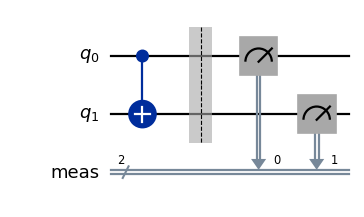

In [15]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import circuit_drawer
from IPython.display import display
import matplotlib.pyplot as plt

# Create a quantum circuit with 2 qubits
qr = QuantumRegister(2, 'q')
ideal_CNOT_circuit = QuantumCircuit(qr)

# Apply CNOT gate (control=0, target=1)
ideal_CNOT_circuit.cx(0, 1)

# Measure both qubits
ideal_CNOT_circuit.measure_all()

# Draw the circuit (assign to variable so it displays in Jupyter)
print("Circuit showing CNOT:")
print("=" * 60)
fig = ideal_CNOT_circuit.draw('mpl', style='iqp', scale=0.8)
fig.tight_layout()
display(fig)


Considering no error and ideal gate: this is how the results look

**CNOT gate matrix** (control = qubit 0, target = qubit 1; basis order |00⟩, |01⟩, |10⟩, |11⟩):

$$\text{CNOT} = \begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0 \end{pmatrix}$$

**Action on computational basis:**

|00⟩ → |00⟩  
|01⟩ → |01⟩  
|10⟩ → |11⟩  
|11⟩ → |10⟩ 

Ideal CNOT gate — measurement results (|00⟩ in, 1024 shots):
{'00': 1024}

Interpretation: With input |00⟩, CNOT leaves it as |00⟩. All counts in 00.


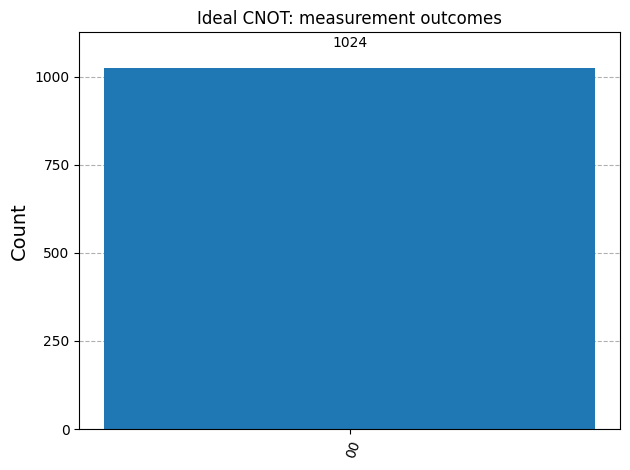

In [17]:
from qiskit.visualization import plot_histogram
from IPython.display import display

# Use the same circuit from the cell tagged ideal_CNOT_circuit (run that cell first)
SHOTS = 1024

try:
    from qiskit_aer import AerSimulator
    from qiskit import transpile
    sim = AerSimulator()
    job = sim.run(transpile(ideal_CNOT_circuit, sim), shots=SHOTS)
    counts = job.result().get_counts()
except ImportError:
    # No qiskit_aer: get counts from statevector (core qiskit only)
    from qiskit.quantum_info import Statevector
    qc_no_meas = ideal_CNOT_circuit.remove_final_measurements(inplace=False)
    sv = Statevector(qc_no_meas)
    n = qc_no_meas.num_qubits
    probs = sv.probabilities()
    counts = {format(i, f"0{n}b"): int(round(p * SHOTS)) for i, p in enumerate(probs) if p > 0}
    # Normalize so sum equals SHOTS (rounding can leave 1023 or 1025)
    total = sum(counts.values())
    if total != SHOTS and counts:
        key = list(counts.keys())[0]
        counts[key] += SHOTS - total

print("Ideal CNOT gate — measurement results (|00⟩ in, 1024 shots):")
print("=" * 55)
print(counts)
print("\nInterpretation: With input |00⟩, CNOT leaves it as |00⟩. All counts in 00.")

fig = plot_histogram(counts, title="Ideal CNOT: measurement outcomes")
fig.tight_layout()
display(fig)

### X error on Control Qubit

Circuit showing X error on Contol Qubit propagating through CNOT:


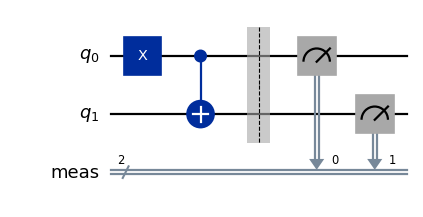

In [12]:
# Create a quantum circuit with 2 qubits
qr = QuantumRegister(2, 'q')
circuit = QuantumCircuit(qr)


# Apply X error on control qubit (qubit 0)
circuit.x(0)

# Apply CNOT gate (control=0, target=1)
circuit.cx(0, 1)

# Measure both qubits
circuit.measure_all()

# Draw the circuit (assign to variable so it displays in Jupyter)
print("Circuit showing X error on Contol Qubit propagating through CNOT:")
print("=" * 60)
fig = circuit.draw('mpl', style='iqp', scale=0.8)
fig.tight_layout()
display(fig)


### X error on Target Qubit 

Circuit showing X error on Target Qubit propagating through CNOT:


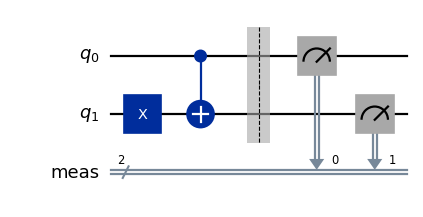

In [ ]:
# Create a quantum circuit with 2 qubits
qr = QuantumRegister(2, 'q')
circuit = QuantumCircuit(qr)


# Apply X error on target qubit (qubit 1)
circuit.x(1)

# Apply CNOT gate (control=0, target=1)
circuit.cx(0, 1)

# Measure both qubits
circuit.measure_all()

# Draw the circuit (assign to variable so it displays in Jupyter)
print("Circuit showing X error on Target Qubit propagating through CNOT:")
print("=" * 60)
fig = circuit.draw('mpl', style='iqp', scale=0.8)
fig.tight_layout()
display(fig)


In [3]:
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_bloch_multivector
import numpy as np

# Demonstrate error propagation with statevector simulation
print("Statevector Analysis of X Error on Target Qubit")
print("=" * 60)

# Initial state: |00⟩
initial_state = Statevector.from_label('00')
print(f"\nInitial state: |00⟩")
print(f"Statevector: {initial_state}")

# Apply X error on target qubit (qubit 1)
circuit_error = QuantumCircuit(2)
circuit_error.x(1)
state_after_error = initial_state.evolve(circuit_error)
print(f"\nAfter X error on target qubit (q1):")
print(f"Statevector: {state_after_error}")
print(f"State: |01⟩")

# Apply CNOT
circuit_cnot = QuantumCircuit(2)
circuit_cnot.cx(0, 1)
state_final = state_after_error.evolve(circuit_cnot)
print(f"\nAfter CNOT gate:")
print(f"Statevector: {state_final}")
print(f"State: |11⟩")

print("\n" + "=" * 60)
print("Key Insight:")
print("X error on target qubit |01⟩ → CNOT → |11⟩")
print("The X error on target propagates to affect the control qubit!")
print("This demonstrates: CNOT · X_t = X_t · X_c · CNOT")


Statevector Analysis of X Error on Target Qubit

Initial state: |00⟩
Statevector: Statevector([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))

After X error on target qubit (q1):
Statevector: Statevector([0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
            dims=(2, 2))
State: |01⟩

After CNOT gate:
Statevector: Statevector([0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
            dims=(2, 2))
State: |11⟩

Key Insight:
X error on target qubit |01⟩ → CNOT → |11⟩
The X error on target propagates to affect the control qubit!
This demonstrates: CNOT · X_t = X_t · X_c · CNOT


### Y error on Control Qubit 

### Y error on Target Qubit 

### Z error on Control Qubit 

### Z error on Target Qubit 